### Load Movie Datasets

In [90]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/learn_ML_LKS/csv/imdb_movies.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


### See preview of datasets

In [91]:
df.head(2)

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU


"overview" columns isn't needed for machine learning, so we dropped<br>
There is float on score, we must round<br>
And the name of columns i changed to easyl to analysis soon

In [92]:
df.drop(columns=['overview'], inplace=True)
df["score"] = df["score"].astype(int)
df["date_x"] = pd.to_datetime(df["date_x"])

In [93]:
df.columns

Index(['names', 'date_x', 'score', 'genre', 'crew', 'orig_title', 'status',
       'orig_lang', 'budget_x', 'revenue', 'country'],
      dtype='object')

__Rename column names__

In [94]:
df.rename(columns={
    "names": "movie_title",
    "date_x": "date",
    "orig_title": "original_title",
    "orig_lang": "language",
    "budget_x": "budget"
}, inplace=True)

In [95]:
df.tail(2)

,movie_title,date,score,genre,crew,original_title,status,language,budget,revenue,country
10176,Darkman II: The Return of Durant,1995-07-11,55,"Action, Adventure, Science Fiction, Thriller, ...","Larry Drake, Robert G. Durant, Arnold Vosloo, ...",Darkman II: The Return of Durant,Released,English,116000000.0,475661306.0,US
10177,The Swan Princess: A Royal Wedding,2020-07-20,70,"Animation, Family, Fantasy","Nina Herzog, Princess Odette (voice), Yuri Low...",The Swan Princess: A Royal Wedding,Released,English,92400000.0,539401838.6,GB


### Check duplicate and miss values

In [96]:
print(f"Duplicated Values: {df.duplicated().sum()}")

df.isna().sum().to_frame().T

Duplicated Values: 0


,movie_title,date,score,genre,crew,original_title,status,language,budget,revenue,country
0,0,0,0,85,56,0,0,0,0,0,0


Zero duplicated values but there is a two columns miss values

In [97]:
df.dropna(inplace=True)

df.isna().sum().to_frame().T

,movie_title,date,score,genre,crew,original_title,status,language,budget,revenue,country
0,0,0,0,0,0,0,0,0,0,0,0


__See descripition__
+ Numerical description

In [98]:
df.score.describe().T

,score
count,10052.00000
mean,63.82700
std,12.78271
min,0.00000
25%,59.00000
50%,65.00000
75%,71.00000
max,100.00000


+ Categorical description

In [99]:
df.describe(include="object").T

,count,unique,top,freq
movie_title,10052,9538,Pinocchio,12
genre,10052,2300,Drama,556
crew,10052,9857,"Robert Armstrong, Carl Denham, Fay Wray, Ann D...",3
original_title,10052,9614,Pinocchio,12
status,10052,3,Released,10007
language,10052,53,English,7381
country,10052,57,AU,4880


__Split columns names to numberical and categorical__

In [100]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['score', 'budget', 'revenue']
Categorical columns: ['movie_title', 'genre', 'crew', 'original_title', 'status', 'language', 'country']


See outlier in boxplot

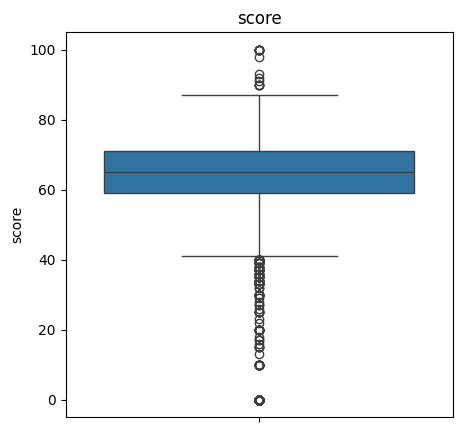

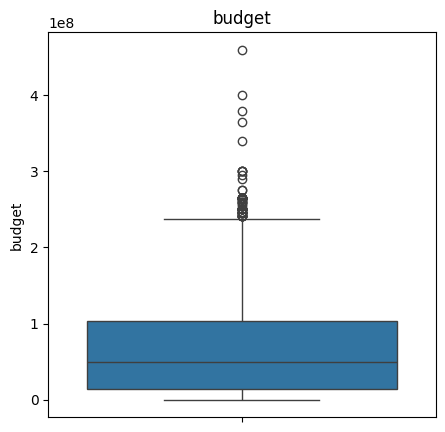

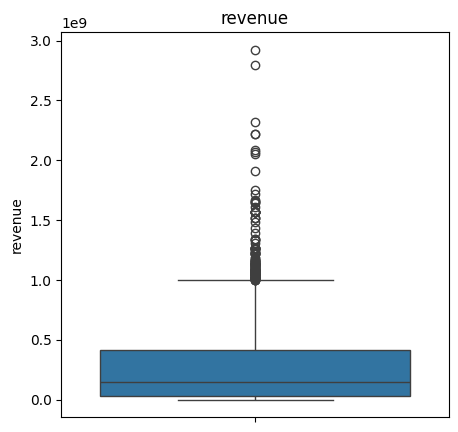

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
  plt.figure(figsize=(5, 5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

There is normal numerical values

# Movie recomendation process

In [102]:
recom_data = df.copy()

recom_data["index"] = range(0, len(df))

recom_data = recom_data.set_index("index").reset_index()
recom_data.head(2)

,index,movie_title,date,score,genre,crew,original_title,status,language,budget,revenue,country
0,0,Creed III,2023-03-02,73,"Drama, Action","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,1,Avatar: The Way of Water,2022-12-15,78,"Science Fiction, Adventure, Action","Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU


In [103]:
features = ["genre", "crew", "language"]

combined_features = recom_data["genre"]+' '+recom_data["crew"]+' '+recom_data["language"]

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tf_vec = TfidfVectorizer()
feature_vector = tf_vec.fit_transform(combined_features)

similarity = cosine_similarity(feature_vector)

Get input of movie name

In [105]:
import difflib

# movie_name = input("Enter movie name: ")
def get_movie_recomendation(name: str)-> dict:
  movie_titles = recom_data["movie_title"]
  find_close_match = difflib.get_close_matches(name, movie_titles)

  close_match = find_close_match[0]
  index_of_movie = recom_data[recom_data.movie_title == close_match]["index"].values[0]
  simalirity_score = list(enumerate(similarity[index_of_movie]))
  sorted_simalirity_score = sorted(simalirity_score, key=lambda x: x[1], reverse=True)
  clean_simalirity_score = sorted_simalirity_score[1:6]
  print(clean_simalirity_score[0:5])

  i=1

  movie_recomendation = {}

  for movie in clean_simalirity_score:
    index = movie[0]
    movie_title_from_index = recom_data[recom_data.index == index]["movie_title"].values[0]
    if i <= 5:
      movie_recomendation[index] = movie_title_from_index
      i += 1

  return movie_recomendation

In [106]:
get_movie_recomendation("iron man")

[(593, 0.45134121115792836), (449, 0.40641787105326327), (352, 0.3580672807049906), (4012, 0.25567482300615335), (509, 0.23611283761309998)]


{593: 'Iron Man 3',
 449: 'Spider-Man: Homecoming',
 352: 'Iron Man 2',
 4012: 'The Invincible Iron Man',
 509: 'Captain America: Civil War'}

In [107]:
movie_recomendation = get_movie_recomendation("Iron Man")

[(593, 0.45134121115792836), (449, 0.40641787105326327), (352, 0.3580672807049906), (4012, 0.25567482300615335), (509, 0.23611283761309998)]


In [108]:
df.loc[movie_recomendation.keys()]

,movie_title,date,score,genre,crew,original_title,status,language,budget,revenue,country
593,Toy Story 4,2019-06-19,75,"Family, Adventure, Animation, Comedy, Fantasy","Tom Hanks, Woody (voice), Tim Allen, Buzz Ligh...",Toy Story 4,Released,English,200000000.0,1.073065e+09,AU
449,Twilight,2008-12-11,63,"Fantasy, Drama, Romance","Kristen Stewart, Bella Swan, Robert Pattinson,...",Twilight,Released,English,37000000.0,4.022786e+08,AU
352,Free Guy,2021-09-09,76,"Comedy, Adventure, Science Fiction","Ryan Reynolds, Guy, Jodie Comer, Millie Rusk /...",Free Guy,Released,English,110000000.0,3.315266e+08,AU
4012,The Wild Thornberrys Movie,2002-12-20,65,"Animation, Adventure, Family","Lacey Chabert, Eliza Thornberry (voice), Tom K...",The Wild Thornberrys Movie,Released,English,25000000.0,6.069474e+07,US
509,High School Teacher: Maturing,1985-01-15,60,Drama,"Rei Akasaka, Kayoko Ishima, Saeko Kuga, Yumi A...",高校教師・成熟,Released,Japanese,73800000.0,3.463523e+08,JP


# Integration to GUI with Gradio

In [109]:
!pip install gradio

In [110]:
import gradio

def input_of_recomendation(name):
  movie_results = get_movie_recomendation(name)
  string_result = ""

  for i, (index, movie_name) in enumerate(movie_results.items()):
    lang = df.loc[index]["language"]
    string_result += f"{i + 1}. {movie_name}({lang.strip()})\n"

  return string_result

view = gradio.Interface(fn=input_of_recomendation, inputs=["text"], outputs=[gradio.Textbox(label="Recomendation for you", lines=3)])
view.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1db1c11b349eee0e6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [111]:
get_movie_recomendation("spider")

[(1067, 0.11868449500508285), (5667, 0.08397210777880487), (8323, 0.08369570196094014), (8635, 0.07527683390839443), (3336, 0.07091057121647953)]


{1067: 'Homebound',
 5667: 'The Giver',
 8323: 'The Disappearance of Alice Creed',
 8635: "My Name Is Mo'Nique",
 3336: 'The Virtuoso'}

In [112]:
input_of_recomendation("spider")

[(1067, 0.11868449500508285), (5667, 0.08397210777880487), (8323, 0.08369570196094014), (8635, 0.07527683390839443), (3336, 0.07091057121647953)]


"1. Homebound(English)\n2. The Giver(English)\n3. The Disappearance of Alice Creed(English)\n4. My Name Is Mo'Nique(Tagalog)\n5. The Virtuoso(English)\n"